In [17]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline


In [2]:
filename = "data/preprocessed_combined_n.xlsx" # removed an outlier which had 400 for NO3-N

df = pd.read_excel(filename)
df.columns = df.columns.astype(str)

spectral_data = df.iloc[:, 3:436]
output_variable = df.iloc[:, 437:438]


In [3]:
spectral_data.head()
output_variable.head()

,NO3-N
0,87.9
1,2.8
2,0.4
3,54.3
4,7.7


In [4]:
print(spectral_data.shape)
print(output_variable.shape)

(150, 433)
(150, 1)


In [5]:
output_variable.describe()

,NO3-N
count,150.000000
mean,18.012667
std,17.320560
min,0.400000
25%,7.425000
50%,12.300000
75%,22.075000
max,104.200000


Text(0.5, 1.0, 'Output N Distribution')

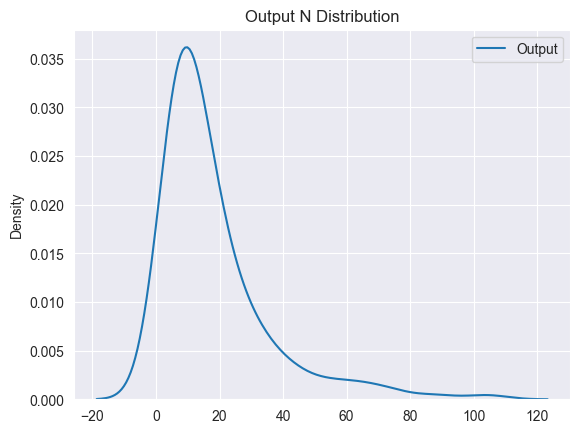

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(output_variable, label='Output')
plt.legend()
plt.title("Output N Distribution")

In [7]:
# No need,skip this

from scipy.signal import savgol_filter
#
X = savgol_filter(spectral_data.values, window_length=11, polyorder=2, deriv=1, axis=1)
y = output_variable.values.ravel()

<Axes: ylabel='Density'>

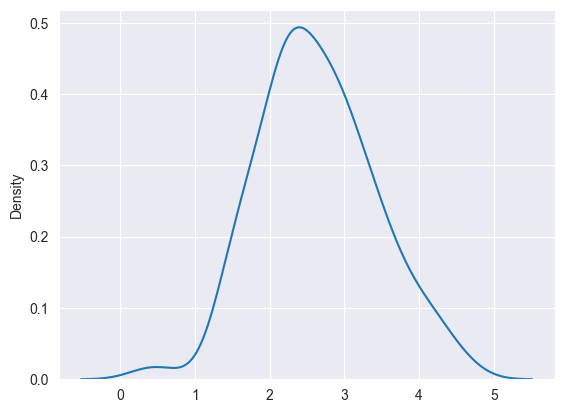

In [8]:
# No need,skip this. added just to check
#
# y_log = np.log1p(output_variable.values.ravel())
# sns.kdeplot(y_log)

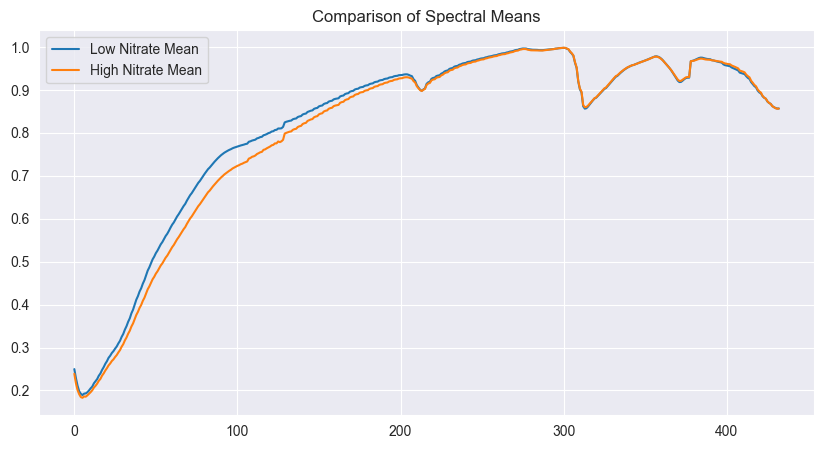

In [42]:
# Checking the wavelength means

X_train_arr = np.array(spectral_data)

median_val = np.median(y)
low_n = X_train_arr[y <= median_val]
high_n = X_train_arr[y > median_val]

plt.figure(figsize=(10, 5))
plt.plot(np.mean(low_n, axis=0), label='Low Nitrate Mean')
plt.plot(np.mean(high_n, axis=0), label='High Nitrate Mean')
plt.legend()
plt.title("Comparison of Spectral Means")
plt.show()

In [19]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=10)),
    ('regressor', Ridge(alpha=1.0))
])

# pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('feat_select', SelectKBest(score_func=f_regression, k=50)),
#     ('rf', RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42))
# ])

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pls', PLSRegression(n_components=10))
# ])

In [51]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

cv = LeaveOneOut()
y_pred = cross_val_predict(pipeline, spectral_data, y, cv=cv)

In [52]:
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"LOOCV R2 Score: {r2:.4f}")
print(f"LOOCV RMSE: {rmse:.4f}")

LOOCV R2 Score: 0.0195
LOOCV RMSE: 17.0932


PLS Regression with VIP selector, and LOOCV

In [53]:
from vip_selector import VIPSelector

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('vip_selector', VIPSelector(threshold=1.4)),
    ('model', PLSRegression(n_components=10))
])

In [55]:
cv = LeaveOneOut()
y_pred = cross_val_predict(pipeline, X, y, cv=cv)


In [56]:
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"Rigorous LOOCV R2 Score: {r2:.4f}")
print(f"Rigorous LOOCV RMSE: {rmse:.4f}")

Rigorous LOOCV R2 Score: -0.1352
Rigorous LOOCV RMSE: 18.3931


Getting VIP wavelengths from PLS regression using all the data

In [8]:
pls = PLSRegression(n_components=10)
pls.fit(spectral_data, y)

,n_components,10
,scale,True
,max_iter,500
,tol,1e-06
,copy,True


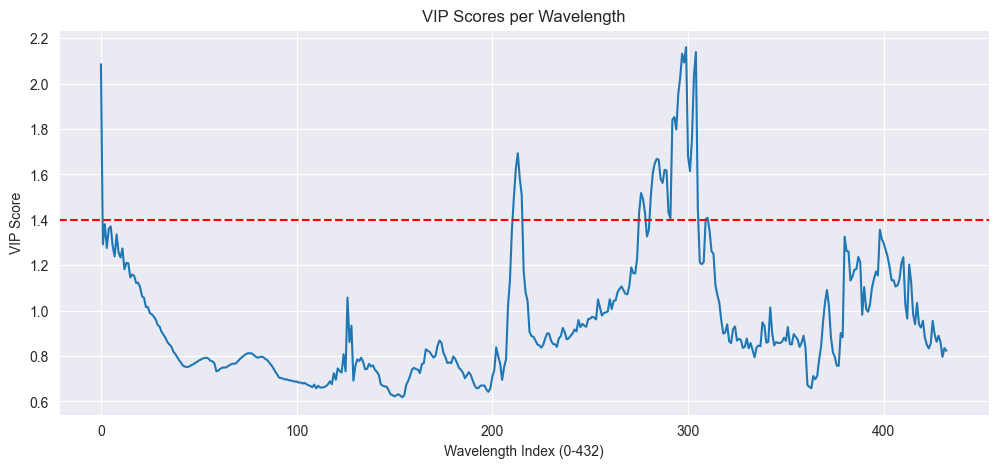

In [9]:
from vip_selector import get_vip, plot_vips

threshold = 1.4

vips = get_vip(pls)
plot_vips(vips, threshold)

In [10]:
selected_indices = np.where(vips > threshold)[0]

In [60]:
selected_indices

array([  0, 211, 212, 213, 214, 215, 275, 276, 277, 278, 281, 282, 283,
       284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296,
       297, 298, 299, 300, 301, 302, 303, 304, 305, 309, 310])

In [11]:
spectral_column_names = df.columns[3:436]

In [12]:
spectral_column_names

Index(['349.866666666667', '354.95', '359.3', '365.15', '369.5', '375.325',
       '379.7', '384.075', '389.9', '394.275',
       ...
       '2464.26666666667', '2467.13333333333', '2474.96666666667', '2479.2',
       '2482.06666666667', '2489.8', '2494', '2500.3', '2504.5',
       '2507.26666666667'],
      dtype='object', length=433)

In [13]:
final_column_names = spectral_column_names[selected_indices]
print(final_column_names.size)
final_column_names

37


Index(['349.866666666667', '1404.35', '1408.05', '1415.45', '1419.15', '1421',
       '1725.2', '1728.8', '1730.6', '1739.55', '1753.85', '1755.65',
       '1764.55', '1768.1', '1775.2', '1778.8', '1780.55', '1789.45', '1793',
       '1800.1', '1803.65', '1810.75', '1814.3', '1817.85', '1824.9',
       '1828.45', '1835.5', '1839.05', '1840.8', '1849.65', '1853.15',
       '1860.2', '1863.75', '1870.75', '1874.25', '1895.35', '1898.85'],
      dtype='object')

In [14]:
X_reduced = spectral_data[final_column_names]

Using the full dataset or the X_reduced (selected wavelengths)

In [37]:


X_train, X_test, y_train, y_test = train_test_split(spectral_data, y, test_size=0.2, random_state=42)
# X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)


In [38]:
X_train

,349.866666666667,354.95,359.3,365.15,369.5,375.325,379.7,384.075,389.9,394.275,...,2464.26666666667,2467.13333333333,2474.96666666667,2479.2,2482.06666666667,2489.8,2494,2500.3,2504.5,2507.26666666667
22,0.242061,0.191091,0.160178,0.173841,0.173748,0.154688,0.167228,0.163204,0.159274,0.170940,...,0.875413,0.875580,0.867178,0.863976,0.860357,0.853952,0.855657,0.853786,0.847672,0.843055
15,0.361333,0.235588,0.205330,0.252762,0.213328,0.206740,0.236767,0.214160,0.221927,0.240118,...,0.932674,0.924815,0.927958,0.922103,0.919514,0.914644,0.913165,0.914428,0.914428,0.911994
65,0.294486,0.248949,0.232765,0.218048,0.205236,0.206664,0.211583,0.205514,0.215351,0.219119,...,0.776570,0.772022,0.763083,0.757530,0.755785,0.747322,0.743462,0.739072,0.737697,0.737961
11,0.311849,0.219691,0.209301,0.232581,0.195688,0.199022,0.216524,0.203912,0.209746,0.221830,...,0.877542,0.873949,0.873393,0.867874,0.860651,0.861022,0.852021,0.859836,0.855873,0.854243
42,0.223714,0.208908,0.189445,0.175717,0.172087,0.169890,0.174863,0.175320,0.178920,0.184015,...,0.925727,0.924954,0.917714,0.917145,0.914013,0.911450,0.908969,0.906650,0.907749,0.907098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.229963,0.205075,0.180498,0.172705,0.160683,0.161949,0.164780,0.163015,0.164313,0.170374,...,0.912659,0.910706,0.907020,0.901736,0.899871,0.896230,0.891701,0.890014,0.889570,0.890058
106,0.182750,0.164332,0.159684,0.145615,0.143632,0.143384,0.143694,0.144376,0.148280,0.149427,...,0.886561,0.883752,0.873546,0.871522,0.869042,0.861068,0.858300,0.856069,0.853466,0.853176
14,0.261431,0.194394,0.198842,0.190763,0.177894,0.190195,0.188448,0.183137,0.192329,0.193146,...,0.851808,0.846664,0.843940,0.839128,0.837222,0.831835,0.824240,0.825329,0.825208,0.823695
92,0.283301,0.251802,0.214142,0.216621,0.204456,0.194305,0.199496,0.202363,0.200814,0.208408,...,0.846907,0.847423,0.841689,0.838176,0.834922,0.830686,0.830531,0.826450,0.821697,0.819682


In [39]:

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=10)),
    ('regressor', Ridge(alpha=1.0))
])

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('regressor', PLSRegression(n_components=10))
# ])

In [40]:


# run this only for the plsregression
#
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__n_components': [5, 10, 15, 20, 25]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best R2: {grid.best_score_}")

ValueError: Invalid parameter 'n_components' for estimator Ridge(). Valid parameters are: ['alpha', 'copy_X', 'fit_intercept', 'max_iter', 'positive', 'random_state', 'solver', 'tol'].

In [41]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred)}")

R2 Score: 0.06859833495509937


Feature selection using lasso

In [43]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor


selector = SelectFromModel(estimator=Lasso(alpha=0.02)).fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)


In [44]:
X_train_selected


array([[0.24206126, 0.17374758, 0.80092333, 0.90467278, 0.96184   ],
       [0.36133327, 0.21332809, 0.79535851, 0.91096112, 0.98284869],
       [0.29448631, 0.20523602, 0.88904403, 0.89932566, 0.91646172],
       [0.31184946, 0.19568841, 0.81057895, 0.90887876, 0.95440234],
       [0.22371365, 0.17208664, 0.80900549, 0.89847468, 0.99109213],
       [0.25650932, 0.19132561, 0.83361101, 0.90148497, 0.98148819],
       [0.23065496, 0.15893302, 0.76665356, 0.89507144, 0.98785337],
       [0.26047971, 0.20864156, 0.77877158, 0.90372114, 0.95826795],
       [0.20565234, 0.23988386, 0.86452033, 0.91721254, 0.9630662 ],
       [0.17045746, 0.16182573, 0.66099585, 0.88062855, 0.9660878 ],
       [0.1846483 , 0.12502729, 0.7761516 , 0.88658691, 0.98681395],
       [0.18830248, 0.14616905, 0.71538968, 0.88899539, 0.97685657],
       [0.19783071, 0.15474673, 0.78169742, 0.89607514, 0.96334563],
       [0.25468425, 0.2065282 , 0.77313374, 0.87632596, 0.95532203],
       [0.27192937, 0.19804976, 0.

In [49]:

pls = PLSRegression(n_components=2)
pls.fit(X_train_selected, y_train)

y_pred = pls.predict(X_test_selected)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: 0.07564495155540352
RMSE: 12.656406238799272


Feature Importance from RF

In [50]:

rf = RandomForestRegressor().fit(X_train, y_train)
selector_rf = SelectFromModel(rf, threshold='median').fit(X_train, y_train)
X_train_selected_rf = selector_rf.transform(X_train)
X_test_selected_rf = selector_rf.transform(X_test)

pls = PLSRegression(n_components=2)
pls.fit(X_train_selected_rf, y_train)

y_pred = pls.predict(X_test_selected_rf)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: -0.27380355172558435
RMSE: 14.857379791108173


RF with GridSearchCV

In [51]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline


pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    # ('pca', PCA(n_components=10)),
    ('model', RandomForestRegressor(random_state=42))
])

# Define parameters to tune
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

# 5-fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='neg_root_mean_squared_error')
grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV RMSE: {-grid.best_score_}")

Best parameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV RMSE: 18.10383134722759


In [52]:
best_rf = grid.best_estimator_

In [53]:
y_test_pred = best_rf.predict(X_test)

print("Test R²:", r2_score(y_test, y_test_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Test R²: -0.18602207283164374
Test MSE: 205.52978429802008
